# 01 — Data Profiling
**Phase 1.5 — Online Retail Sales Analytics**

Goals:
- Row counts and column types for all raw tables
- Null analysis per column
- Outlier and anomaly detection
- Duplicate check
- Distribution of key metrics

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import get_engine
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
engine = get_engine()
print("Connected")

Connected


## 1. Row Counts — All Tables

In [2]:
import sqlalchemy as sa

tables = [
    "customers", "orders", "order_items", "order_payments",
    "order_reviews", "products", "sellers", "geolocation", "category_translation"
]

for t in tables:
    with engine.connect() as conn:
        count = conn.execute(sa.text(f"SELECT COUNT(*) FROM {t}")).scalar()
    print(f"  {t:<30} {count:>9,}")

  customers                         99,441
  orders                            99,441
  order_items                      112,650
  order_payments                   103,886
  order_reviews                     99,224
  products                          32,951
  sellers                            3,095
  geolocation                    1,000,163
  category_translation                  71


## 2. orders — Column Types & Nulls

In [3]:
orders = pd.read_sql("SELECT * FROM orders", engine)
print(orders.dtypes)

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [4]:
null_summary = orders.isnull().sum().rename("null_count").to_frame()
null_summary["null_pct"] = (null_summary["null_count"] / len(orders) * 100).round(2)
null_summary[null_summary["null_count"] > 0].sort_values("null_count", ascending=False)

,null_count,null_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


## 3. order_items — Outlier Detection (price, freight)

In [5]:
order_items = pd.read_sql("SELECT * FROM order_items", engine)
order_items[["price", "freight_value"]].describe().round(2)

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


In [6]:
print(f"Negative prices:         {(order_items['price'] < 0).sum()}")
print(f"Zero prices:             {(order_items['price'] == 0).sum()}")
print(f"Negative freight:        {(order_items['freight_value'] < 0).sum()}")
print(f"p99 price:               {order_items['price'].quantile(0.99):.2f}")
print(f"p99 freight:             {order_items['freight_value'].quantile(0.99):.2f}")

Negative prices:         0
Zero prices:             0
Negative freight:        0
p99 price:               890.00
p99 freight:             84.52


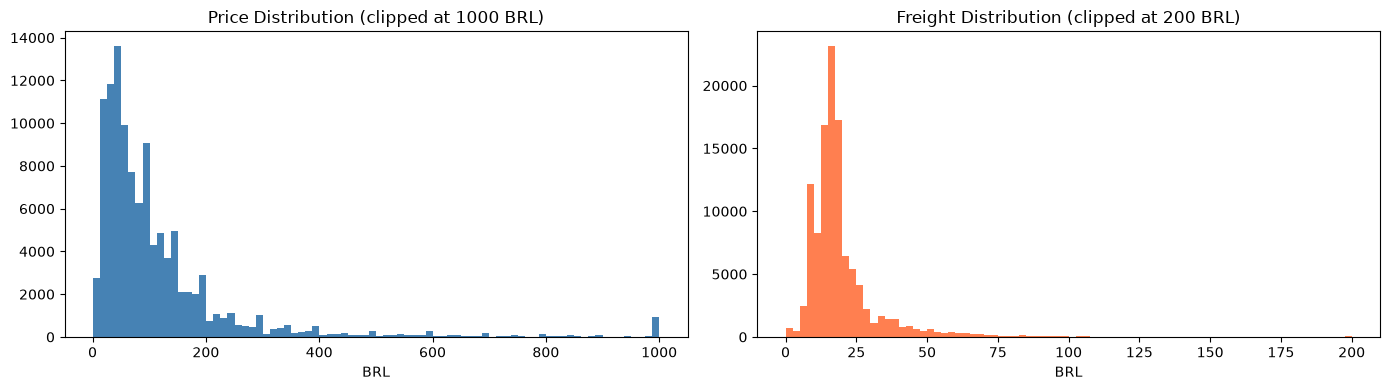

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(order_items["price"].clip(0, 1000), bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Price Distribution (clipped at 1000 BRL)")
axes[0].set_xlabel("BRL")
axes[1].hist(order_items["freight_value"].clip(0, 200), bins=80, color="coral", edgecolor="none")
axes[1].set_title("Freight Distribution (clipped at 200 BRL)")
axes[1].set_xlabel("BRL")
plt.tight_layout()
plt.show()

## 4. order_payments — Outlier Detection

In [8]:
payments = pd.read_sql("SELECT * FROM order_payments", engine)
payments[["payment_value", "payment_installments"]].describe().round(2)

,payment_value,payment_installments
count,103886.00,103886.00
mean,154.10,2.85
std,217.49,2.69
min,0.00,0.00
25%,56.79,1.00
50%,100.00,1.00
75%,171.84,4.00
max,13664.08,24.00


In [9]:
print(f"Negative payment values:     {(payments['payment_value'] < 0).sum()}")
print(f"Zero payment values:         {(payments['payment_value'] == 0).sum()}")
print(f"Max installments:            {payments['payment_installments'].max()}")
print(f"Installments > 24:           {(payments['payment_installments'] > 24).sum()}")

Negative payment values:     0
Zero payment values:         9
Max installments:            24
Installments > 24:           0


## 5. order_reviews — Score & Null Comments

In [10]:
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
print(f"Total reviews:               {len(reviews):,}")
print(f"Null review_comment_title:   {reviews['review_comment_title'].isnull().sum():,}")
print(f"Null review_comment_message: {reviews['review_comment_message'].isnull().sum():,}")
print(f"Null review_creation_date:   {reviews['review_creation_date'].isnull().sum():,}")
reviews["review_score"].value_counts().sort_index()

Total reviews:               99,224
Null review_comment_title:   87,656
Null review_comment_message: 58,247
Null review_creation_date:   0


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

## 6. products — Null & Dimension Check

In [11]:
products = pd.read_sql("SELECT * FROM products", engine)
null_summary = products.isnull().sum().rename("null_count").to_frame()
null_summary["null_pct"] = (null_summary["null_count"] / len(products) * 100).round(2)
null_summary[null_summary["null_count"] > 0].sort_values("null_count", ascending=False)

,null_count,null_pct
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [12]:
print(f"Products with zero weight:       {(products['product_weight_g'] == 0).sum()}")
print(f"Products with null dimensions:   {products[['product_length_cm','product_height_cm','product_width_cm']].isnull().any(axis=1).sum()}")
print(f"Distinct categories (PT):        {products['product_category_name'].nunique()}")
print(f"Null category names:             {products['product_category_name'].isnull().sum()}")

Products with zero weight:       4
Products with null dimensions:   2
Distinct categories (PT):        73
Null category names:             610


## 7. Duplicate Check — All Key Tables

In [13]:
checks = {
    "orders":         ("orders",         "order_id"),
    "customers":      ("customers",       "customer_id"),
    "order_reviews":  ("order_reviews",   "review_id"),
    "products":       ("products",        "product_id"),
    "sellers":        ("sellers",         "seller_id"),
}

for label, (table, pk) in checks.items():
    df = pd.read_sql(f"SELECT {pk} FROM {table}", engine)
    dups = df[pk].duplicated().sum()
    status = "✅" if dups == 0 else "❌"
    print(f"  {status}  {label:<20} duplicate {pk}: {dups:,}")

  ✅  orders               duplicate order_id: 0
  ✅  customers            duplicate customer_id: 0
  ❌  order_reviews        duplicate review_id: 814
  ✅  products             duplicate product_id: 0
  ✅  sellers              duplicate seller_id: 0


In [14]:
# order_items: composite PK = order_id + order_item_id
oi = pd.read_sql("SELECT order_id, order_item_id FROM order_items", engine)
dup_oi = oi.duplicated().sum()
print(f"  {'✅' if dup_oi == 0 else '❌'}  order_items (composite PK): {dup_oi:,} duplicates")

# order_payments: composite PK = order_id + payment_sequential
op = pd.read_sql("SELECT order_id, payment_sequential FROM order_payments", engine)
dup_op = op.duplicated().sum()
print(f"  {'✅' if dup_op == 0 else '❌'}  order_payments (composite PK): {dup_op:,} duplicates")

  ✅  order_items (composite PK): 0 duplicates
  ✅  order_payments (composite PK): 0 duplicates


## 8. Referential Integrity Check

In [15]:
orders_ids    = set(pd.read_sql("SELECT order_id FROM orders", engine)["order_id"])
oi_orders     = set(pd.read_sql("SELECT DISTINCT order_id FROM order_items", engine)["order_id"])
pay_orders    = set(pd.read_sql("SELECT DISTINCT order_id FROM order_payments", engine)["order_id"])
rev_orders    = set(pd.read_sql("SELECT DISTINCT order_id FROM order_reviews", engine)["order_id"])

print(f"order_items orders not in orders:    {len(oi_orders  - orders_ids):,}")
print(f"order_payments orders not in orders: {len(pay_orders - orders_ids):,}")
print(f"order_reviews orders not in orders:  {len(rev_orders - orders_ids):,}")

order_items orders not in orders:    0
order_payments orders not in orders: 0
order_reviews orders not in orders:  0


## 9. Geolocation Duplicate ZIP Codes

In [16]:
geo = pd.read_sql("SELECT * FROM geolocation", engine)
print(f"Total rows:          {len(geo):,}")
print(f"Distinct ZIPs:       {geo['geolocation_zip_code_prefix'].nunique():,}")
dup_zips = geo.groupby("geolocation_zip_code_prefix").size()
print(f"ZIPs with >1 entry:  {(dup_zips > 1).sum():,}")
print(f"Max entries per ZIP: {dup_zips.max()}")

Total rows:          1,000,163
Distinct ZIPs:       19,015
ZIPs with >1 entry:  17,972
Max entries per ZIP: 1146


## 10. Delivery Time Analysis

In [17]:
orders["order_purchase_timestamp"]     = pd.to_datetime(orders["order_purchase_timestamp"],     errors="coerce")
orders["order_delivered_customer_date"]= pd.to_datetime(orders["order_delivered_customer_date"],errors="coerce")
orders["order_estimated_delivery_date"]= pd.to_datetime(orders["order_estimated_delivery_date"],errors="coerce")

delivered = orders[orders["order_status"] == "delivered"].copy()
delivered["actual_days"]    = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["estimated_days"] = (delivered["order_estimated_delivery_date"]  - delivered["order_purchase_timestamp"]).dt.days

print(delivered[["actual_days","estimated_days"]].describe().round(1).to_string())
print(f"\nDelivered late (actual > estimated): {(delivered['actual_days'] > delivered['estimated_days']).sum():,}")
print(f"Negative delivery times (anomaly):   {(delivered['actual_days'] < 0).sum():,}")

       actual_days  estimated_days
count     96470.00        96478.00
mean         12.10           23.40
std           9.60            8.80
min           0.00            2.00
25%           6.00           18.00
50%          10.00           23.00
75%          15.00           28.00
max         209.00          155.00

Delivered late (actual > estimated): 7,307
Negative delivery times (anomaly):   0


In [18]:
engine.dispose()
print("Done.")

Done.
